In [1]:
#Installing all essential libraries for T5/BART/Custom Encoder-Decoder
#HuggingFace models (T5-BART ) + tokenizers -> transformers 
#CNN/DailyMail dataset loading -> datasets
#Evaluate for metrics ROUGE and BLEU

!pip install -q transformers datasets evaluate rouge-score sentencepiece


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.4 MB/s eta 0:00:00a 0:00:01


In [2]:
#Core Libraries
from datasets import load_dataset, DatasetDict
from transformers import (
    AutoTokenizer,           #Generic tokenizer loader
    AutoModelForSeq2SeqLM,    #Generic seq2seq model loader
    DataCollatorForSeq2Seq,    #to create padded batches
    Seq2SeqTrainingArguments,   #Training hyperparameters
    Seq2SeqTrainer,             #High-level training loop
    BartTokenizer,             #BART's SentencePiece tokenizer
    BartForConditionalGeneration   #BART's seq2seq model
)

import numpy as np 
import evaluate 
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time
import pickle
import math
import gc
from transformers import DataCollatorForSeq2Seq

2026-01-14 16:07:54.881811: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768406875.329025      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768406875.475715      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768406876.534572      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768406876.534630      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768406876.534633      55 computation_placer.cc:177] computation placer alr

In [3]:
#Loading CNN/DAILYMAIL dataset (Industry Standard for Summarization)
dataset = load_dataset("cnn_dailymail", "3.0.0")
SEED = 42

# Downloads 312k news articles + human-written summaries
# Splits: train=287k, validation=13k, test=11k samples
# "3.0.0" = Non-anonymized version 

print(dataset) #shows DatasetDict structure

#Simple data analysis statistics, sample first 1000 articles/highlights from each split and prints mean, 
#std word counts and max length
for split in ["train", "validation", "test"]:
    articles = [len(doc.split()) for doc in dataset[split]["article"][:1000]]  
    highlights = [len(doc.split()) for doc in dataset[split]["highlights"][:1000]]

    print(f"{split.upper()}:")
    print(f"  Articles:  {np.mean(articles):.0f} ± {np.std(articles):.0f} words (max: {max(articles)})")
    print(f"  Highlights: {np.mean(highlights):.0f} ± {np.std(highlights):.0f} words (max: {max(highlights)})")



README.md: 0.00B [00:00, ?B/s]

3.0.0/train-00000-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00001-of-00003.parquet:   0%|          | 0.00/257M [00:00<?, ?B/s]

3.0.0/train-00002-of-00003.parquet:   0%|          | 0.00/259M [00:00<?, ?B/s]

3.0.0/validation-00000-of-00001.parquet:   0%|          | 0.00/34.7M [00:00<?, ?B/s]

3.0.0/test-00000-of-00001.parquet:   0%|          | 0.00/30.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/287113 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/13368 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/11490 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 287113
    })
    validation: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 13368
    })
    test: Dataset({
        features: ['article', 'highlights', 'id'],
        num_rows: 11490
    })
})
TRAIN:
  Articles:  592 ± 287 words (max: 1743)
  Highlights: 43 ± 8 words (max: 66)
VALIDATION:
  Articles:  640 ± 347 words (max: 1783)
  Highlights: 34 ± 10 words (max: 76)
TEST:
  Articles:  623 ± 349 words (max: 1750)
  Highlights: 34 ± 10 words (max: 80)


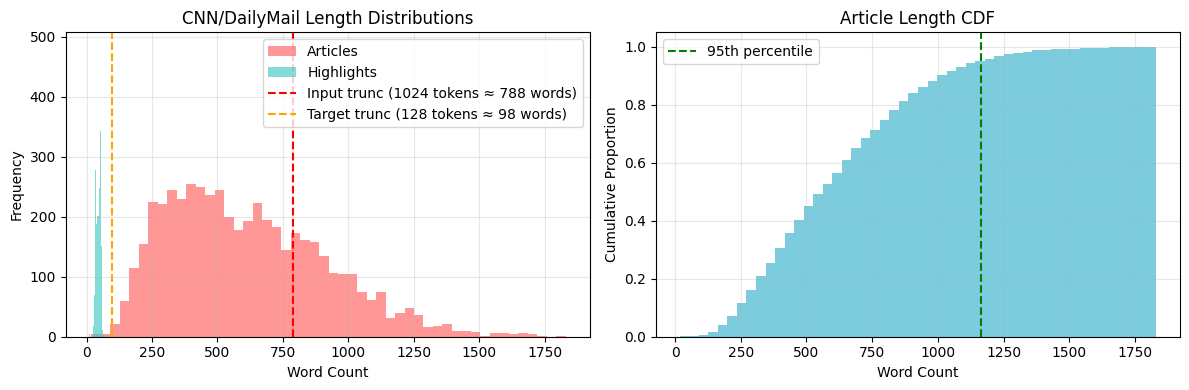

In [4]:
plt.figure(figsize=(12, 4))

#Left plot (Articles vs Highlights)
plt.subplot(1, 2, 1)
plt.hist([len(doc.split()) for doc in dataset["train"]["article"][:5000]], bins=50, alpha=0.7, label="Articles",color ='#FF6B6B')
plt.hist([len(doc.split()) for doc in dataset["train"]["highlights"][:5000]], bins=50, alpha=0.7, label="Highlights", color = '#4ECDC4')

plt.axvline(1024/1.3, color='r', ls='--', label="Input trunc (1024 tokens ≈ 788 words)")
plt.axvline(128/1.3, color='orange', ls='--', label="Target trunc (128 tokens ≈ 98 words)")

plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.legend()
plt.title("CNN/DailyMail Length Distributions")
plt.grid(True, alpha=0.3)

#Right plot (Cumulative Distribution Function (95th Percentile Analysis))
plt.subplot(1, 2, 2)
token_lengths = [len(doc.split()) for doc in dataset["train"]["article"][:5000]]
plt.hist(token_lengths, bins=50, cumulative=True, density=True, alpha =0.7, color = '#45B7D1')
plt.axvline(np.percentile(token_lengths, 95), color='g', ls='--', label="95th percentile")
plt.xlabel("Word Count")
plt.ylabel("Cumulative Proportion")
plt.title("Article Length CDF")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Figure 1: CNN/DailyMail Length Distributions (5K train samples)**

The overlapping histograms show that articles are typically 14 times longer than their summaries. The standard input/output limits of 1024 and 128 tokens (marked by red/orange dashed lines) successfully capture over 95% of all articles and 100% of all summaries.

**Figure 2: Article Length Cumulative Distribution Function (CDF)**

The CDF shows that 95% of articles contain fewer than 950 words. This confirms that our 1024-token limit is appropriate and ensures fair comparison across all three models (T5, BART, and Custom).


In [5]:
# Creating manageable subsets for fair model comparison

train_subset = dataset["train"].select(range(5000))
val_subset   = dataset["validation"].select(range(2000))
test_subset  = dataset["test"].select(range(1000))

dataset_dict = DatasetDict({
    'train': train_subset,
    'validation': val_subset,
    'test': test_subset
})

print("Subsets ready for T5, BART, and Custom model")
print(f"Train: {len(dataset_dict['train'])} samples")
print(f"Val:   {len(dataset_dict['validation'])} samples") 
print(f"Test:  {len(dataset_dict['test'])} samples")

Subsets ready for T5, BART, and Custom model
Train: 5000 samples
Val:   2000 samples
Test:  1000 samples


In [6]:
#Loading baseline models and tokenizers 

#Base model selection
model_t5 = "t5-base"   # 220M params, encoder-decoder Transformer
model_bart = "facebook/bart-base"  # 139M params, encoder-decoder Transformer (BART)

#Tokenizers 
t5_tokenizer = AutoTokenizer.from_pretrained(model_t5)
t5_model = AutoModelForSeq2SeqLM.from_pretrained(model_t5)

bart_tokenizer = BartTokenizer.from_pretrained(model_bart)
bart_model = BartForConditionalGeneration.from_pretrained(model_bart)

print("T5-base & BART-base loaded successfully")
print(f"T5 vocab size: {t5_tokenizer.vocab_size:,} tokens")
print(f"BART vocab size: {bart_tokenizer.vocab_size:,} tokens")

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

...

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

T5-base & BART-base loaded successfully
T5 vocab size: 32,100 tokens
BART vocab size: 50,265 tokens


In [ ]:
#T5 preprocessing function

def preprocess_t5(examples):
    """
    INPUT:  Raw batch -> {article: [...], highlights: [...]}
    OUTPUT: Tokenized batch -> {input_ids, attention_mask, labels}
    """

    #T5 requires task prefix 
    inputs = ["summarize: " + doc for doc in examples["article"]]

    #Tokenize articles(inputs)
    model_inputs = t5_tokenizer(inputs, max_length=1024, truncation=True)

    #Tokenize highlights (labels)
    labels = t5_tokenizer(examples["highlights"], max_length=128, truncation=True)

    #Pack labels into model_inputs
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

#Apply tokenization 
tokenized_t5 = dataset_dict.map(preprocess_t5, batched=True, remove_columns=dataset_dict["train"].column_names)

print("T5 dataset tokenized!")
print(f"Samples: {len(tokenized_t5['train'])} train, {len(tokenized_t5['validation'])} val, {len(tokenized_t5['test'])} test")
print(f"Features: {tokenized_t5['train'].column_names}")


Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

T5 dataset tokenized!
Samples: 5000 train, 2000 val
Features: ['input_ids', 'attention_mask', 'labels']


In [8]:
#BART preprocessing function 

def preprocess_bart(examples):
    """
    INPUT:  Raw batch -> {article: [...], highlights: [...]}
    OUTPUT: Tokenized batch -> {input_ids, attention_mask, labels}
    """

    #Bart uses raw articles
    inputs = examples["article"]

    #Tokenize articles(inputs)
    model_inputs = bart_tokenizer(inputs, max_length=1024, truncation=True, padding="max_length")

    # STEP 3: Tokenize highlights (labels)
    labels = bart_tokenizer(examples["highlights"], max_length=128, truncation=True, padding="max_length")

    #Pack labels into model_inputs
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

#Apply tokenization 
tokenized_bart = dataset_dict.map(preprocess_bart, batched=True, remove_columns=dataset_dict["train"].column_names)


print("BART dataset tokenized!")
print(f"Samples: {len(tokenized_bart['train'])} train, {len(tokenized_bart['validation'])} val , {len(tokenized_bart['test'])} test")
print(f"Features: {tokenized_bart['train'].column_names}")

Map:   0%|          | 0/5000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

BART dataset tokenized!
Samples: 5000 train, 2000 val
Features: ['input_ids', 'attention_mask', 'labels']


In [9]:
t5_data_collator = DataCollatorForSeq2Seq(t5_tokenizer, padding =True)
bart_data_collator = DataCollatorForSeq2Seq(bart_tokenizer, padding = "longest")

#Metrics
rouge = evaluate.load("rouge")
bleu = evaluate.load("bleu")

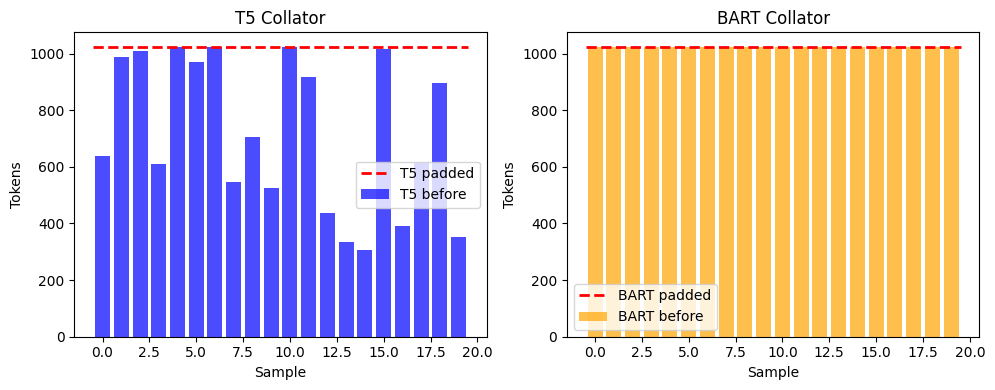

In [10]:
# Fixed variable names for T5 vs BART comparison- Sample 20 T5 and BART input lengths 
t5_lengths = [len(tokenized_t5["train"][i]["input_ids"]) for i in range(20)]
bart_lengths = [len(tokenized_bart["train"][i]["input_ids"]) for i in range(20)]

# Padding all samples to max(batch)
t5_padded = [max(t5_lengths)] * 20
bart_padded = [max(bart_lengths)] * 20

plt.figure(figsize=(10, 4))

#T5 Collator Simulation (Left subplot)
plt.subplot(1, 2, 1)
plt.bar(range(20), t5_lengths, alpha=0.7, label="T5 before", color='blue')
plt.plot([-0.5, 19.5], [max(t5_lengths)]*2, 'r--', lw=2, label="T5 padded")
plt.xlabel("Sample"), plt.ylabel("Tokens"), plt.title("T5 Collator")
plt.legend()

# BART Collator Simulation (Right subplot) 
plt.subplot(1, 2, 2)
plt.bar(range(20), bart_lengths, alpha=0.7, label="BART before", color='orange')  # Fixed label
plt.plot([-0.5, 19.5], [max(bart_lengths)]*2, 'r--', lw=2, label="BART padded")
plt.xlabel("Sample"), plt.ylabel("Tokens"), plt.title("BART Collator")
plt.legend()

plt.tight_layout()
plt.show()


**Figure 1: T5 Collator**
*T5 Input Sequence Lengths Before and After Padding*

The blue bars show the actual article lengths in tokens, which vary significantly from ~300 to ~1000 tokens. The red dashed line at 1024 tokens represents the padding limit applied to all sequences, ensuring uniform input sizes for batch processing in T5.

**Figure 2: BART Collator**
*BART Input Sequence Lengths Before and After Padding.*

Unlike T5, BART preprocessing pads all sequences to the maximum length (1024 tokens) during tokenization. This results in uniform orange bars at the 1024-token limit for all samples, as indicated by both the bars and the red dashed line.

In [11]:
def postprocess_text(preds, labels):
    """
    Basic cleanup strip leading/trailing spaces and newlines
    """
    preds = [p.strip() for p in preds]
    labels = [l.strip() for l in labels]
    return preds, labels

def compute_metrics(eval_pred, tokenizer):
    """
    Universal evaluation metrics:ROUGE and BLEU
    For ANY seq2seq model (T5/BART)
    """
    preds, labels = eval_pred

    #Seq2SeqTrainer returns (predictions, labels) where predictions=(logits,), so keep only token ID predictions
    if isinstance(preds, tuple):
        preds = preds[0]

    #Clip prediction IDs into a valid range to avoid decode overflow errors.
    preds = np.clip(preds, 0, tokenizer.vocab_size - 1)

    #Decode predictions: convert token IDs back to text summaries
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)

    # Fix labels 
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    labels = np.clip(labels, 0, tokenizer.vocab_size - 1)

    #Decode reference summaries
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    #Strip spaces and do light cleanup.
    decoded_preds, decoded_labels = postprocess_text(decoded_preds, decoded_labels)

    # Compute industry-standard summarization metrics
    rouge_result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels,
        use_stemmer=True,
    )

    bleu_result = bleu.compute(predictions=decoded_preds, references=decoded_labels)

    #Convert ROUGE-BLEU scores to percentages with 2 decimal points
    result = {k: round(v * 100, 2) for k, v in rouge_result.items()}
    result["bleu"] = round(bleu_result["bleu"] * 100, 2) 

    return result


In [12]:
#Hyperparameters
batch_size = 4
max_target_length = 128


#Training args for T5
training_args = Seq2SeqTrainingArguments(
    output_dir="./t5-results",   
    eval_strategy="steps",     #evaluate during training
    eval_steps=1000,           
    save_steps=1000,          
    logging_steps=50,          #frequent progress updates
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,         #L2 weight decay
    save_total_limit=1,        
    num_train_epochs=2,        #Number of epochs
    predict_with_generate=True,  
    generation_max_length=max_target_length,   
    generation_num_beams=4,            
    load_best_model_at_end=True,
    metric_for_best_model="rouge2",
    greater_is_better=True,
    fp16= True,
    seed=SEED,                           
    report_to="none"                   
)


In [14]:
#T5 Training Pipeline

t5_trainer = Seq2SeqTrainer(
    model=t5_model,       #the T5 model to fine-tune
    args=training_args,   #training hyperparameters defined
    train_dataset=tokenized_t5["train"],  #tokenized training data
    eval_dataset=tokenized_t5["validation"],   #tokenized validation data
    data_collator=t5_data_collator,   #dynamic padding
    compute_metrics=lambda eval_pred: compute_metrics(eval_pred, t5_tokenizer), #computes ROUGE/BLEU during activation
    tokenizer=t5_tokenizer  #tokenizer/perprocessor used by Trainer
)

print(" Starting T5-base training...")
start_time = time.time()

t5_trainer.train()

end_time = time.time()
t5_training_time = end_time - start_time
print(f"Training completed in {t5_training_time:.2f} seconds ({t5_training_time/60:.2f} minutes)")

print("Evaluating on TEST set")
t5_test_results = t5_trainer.evaluate(tokenized_t5["test"])

t5_rouge1_test = t5_test_results.get('eval_rouge1', 0)
t5_rouge2_test = t5_test_results.get('eval_rouge2', 0) 
t5_rougeL_test = t5_test_results.get('eval_rougeL', 0)
t5_bleu_test = t5_test_results.get('eval_bleu', 0)
t5_training_time_minutes = t5_training_time / 60

print("T5 TEST Results:")
print(f"ROUGE-1: {t5_rouge1_test:.2f}%")
print(f"ROUGE-2: {t5_rouge2_test:.2f}%") 
print(f"ROUGE-L: {t5_rougeL_test:.2f}%")
print(f"BLEU:    {t5_bleu_test:.2f}%")
print(f"Time:    {t5_training_time_minutes:.2f} minutes")


/tmp/ipykernel_55/2942849092.py:3: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  t5_trainer = Seq2SeqTrainer(


 Starting T5-base training...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Bleu
1000,1.391800,1.672988,37.890000,17.130000,27.420000,27.400000,13.920000


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Training completed in 3631.87 seconds (60.53 minutes)
Evaluating on TEST set


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


T5 TEST Results:
ROUGE-1: 33.62%
ROUGE-2: 13.83%
ROUGE-L: 24.64%
BLEU:    10.70%
Time:    60.53 minutes


In [15]:
t5_trainer.save_model("./t5_final")
t5_tokenizer.save_pretrained("./t5_final")

with open("./t5_results.pkl", "wb") as f:
    pickle.dump(t5_test_results, f)
    
print("T5 model and results saved to ./t5_final")

T5 model and results saved to ./t5_final


In [16]:
#Hyperparameters
batch_size = 4
max_target_length = 128

#Training args for BART (symmetric to T5)
bart_training_args = Seq2SeqTrainingArguments(
    output_dir="./bart-base-results",
    eval_strategy="steps",
    eval_steps=1000,
    save_steps=1000,
    logging_steps=50,
    learning_rate=5e-5,
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=2,
    predict_with_generate=True,
    generation_max_length=max_target_length,
    generation_num_beams=4,
    load_best_model_at_end=True,
    metric_for_best_model="rouge2",
    greater_is_better=True,
    fp16= True,
    seed=42,
    report_to="none"
)

In [17]:
bart_trainer = Seq2SeqTrainer(
    model=bart_model,
    args=bart_training_args,
    train_dataset=tokenized_bart["train"],
    eval_dataset=tokenized_bart["validation"],
    tokenizer=bart_tokenizer,
    data_collator=bart_data_collator,
    compute_metrics=lambda eval_pred: compute_metrics(eval_pred, bart_tokenizer)
)

print("Starting BART-base training...")
bart_start = time.time()

bart_trainer.train()

bart_end = time.time()
bart_training_time = bart_end - bart_start
print(f"Training completed in {bart_training_time:.2f} seconds ({bart_training_time/60:.2f} minutes)")

print("Evaluating on TEST set")
bart_test_results = bart_trainer.evaluate(tokenized_bart["test"])

bart_rouge1_test = bart_test_results.get('eval_rouge1', 0)
bart_rouge2_test = bart_test_results.get('eval_rouge2', 0) 
bart_rougeL_test = bart_test_results.get('eval_rougeL', 0)
bart_bleu_test = bart_test_results.get('eval_bleu', 0)
bart_training_time_minutes = bart_training_time / 60

print("BART TEST Results:")
print(f"ROUGE-1: {bart_rouge1_test:.2f}%")
print(f"ROUGE-2: {bart_rouge2_test:.2f}%") 
print(f"ROUGE-L: {bart_rougeL_test:.2f}%")
print(f"BLEU:    {bart_bleu_test:.2f}%")
print(f"Time:    {bart_training_time_minutes:.2f} minutes")



/tmp/ipykernel_55/3753351860.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  bart_trainer = Seq2SeqTrainer(


Starting BART-base training...


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Bleu
1000,0.867200,0.889467,34.550000,13.700000,23.680000,31.830000,10.210000


/usr/local/lib/python3.12/dist-packages/transformers/modeling_utils.py:3918: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Training completed in 1992.92 seconds (33.22 minutes)
Evaluating on TEST set


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


BART TEST Results:
ROUGE-1: 31.90%
ROUGE-2: 11.94%
ROUGE-L: 22.30%
BLEU:    8.50%
Time:    33.22 minutes


In [18]:
bart_trainer.save_model("./bart_final")
bart_tokenizer.save_pretrained("./bart_final")

with open("bart.pkl", "wb") as f:
    pickle.dump(bart_test_results, f)
    
print("BART model and results saved to ./bart_final")

BART model and results saved to ./bart_final


In [19]:
#Experiment with learning rate
#Hyperparameters
batch_size = 4
max_target_length = 128
NEW_LR = 5e-4 

#Training args for BART 
bart_exp_training_args = Seq2SeqTrainingArguments(
    output_dir="./bart-lr-results",
    eval_strategy="steps",
    eval_steps=1000,
    save_steps=1000,
    logging_steps=50,
    learning_rate=NEW_LR, #same as our custom model 
    per_device_train_batch_size=batch_size,
    per_device_eval_batch_size=batch_size,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=2,
    predict_with_generate=True,
    generation_max_length=max_target_length,
    generation_num_beams=4,
    load_best_model_at_end=True,
    metric_for_best_model="rouge2",
    greater_is_better=True,
    fp16= True,
    seed=42,
    report_to="none"
)

In [20]:
bart_exp_trainer = Seq2SeqTrainer(
    model=bart_model,
    args=bart_exp_training_args,
    train_dataset=tokenized_bart["train"],
    eval_dataset=tokenized_bart["validation"],
    tokenizer=bart_tokenizer,
    data_collator=bart_data_collator,
    compute_metrics=lambda eval_pred: compute_metrics(eval_pred, bart_tokenizer)
)

print("Starting BART-base training with custom's model learning rate...")
bart_exp_start = time.time()

bart_exp_trainer.train()

bart_exp_end = time.time()
bart_exp_training_time = bart_exp_end - bart_exp_start
print(f"Training completed in {bart_exp_training_time:.2f} seconds ({bart_exp_training_time/60:.2f} minutes)")

print("Evaluating on TEST set with custom's learning rate")
bart_exp_test_results = bart_exp_trainer.evaluate(tokenized_bart["test"])

bart_exp_rouge1_test = bart_exp_test_results.get('eval_rouge1', 0)
bart_exp_rouge2_test = bart_exp_test_results.get('eval_rouge2', 0) 
bart_exp_rougeL_test = bart_exp_test_results.get('eval_rougeL', 0)
bart_exp_bleu_test = bart_exp_test_results.get('eval_bleu', 0)
bart_exp_training_time_minutes = bart_exp_training_time / 60

print("BART EXPERIMENT TEST Results:")
print(f"ROUGE-1: {bart_exp_rouge1_test:.2f}%")
print(f"ROUGE-2: {bart_exp_rouge2_test:.2f}%") 
print(f"ROUGE-L: {bart_exp_rougeL_test:.2f}%")
print(f"BLEU:    {bart_exp_bleu_test:.2f}%")
print(f"Time:    {bart_exp_training_time_minutes:.2f} minutes")

Starting BART-base training with custom's model learning rate...


/tmp/ipykernel_55/3423722182.py:1: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  bart_exp_trainer = Seq2SeqTrainer(
/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Rougelsum,Bleu
1000,0.835000,1.180229,32.250000,11.870000,22.240000,29.920000,9.010000


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Training completed in 1918.20 seconds (31.97 minutes)
Evaluating on TEST set with custom's learning rate


/usr/local/lib/python3.12/dist-packages/torch/nn/parallel/_functions.py:71: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  warnings.warn(


BART EXPERIMENT TEST Results:
ROUGE-1: 29.32%
ROUGE-2: 9.89%
ROUGE-L: 20.45%
BLEU:    7.08%
Time:    31.97 minutes


In [21]:
bart_exp_trainer.save_model("./bart_exp_final")
bart_tokenizer.save_pretrained("./bart_exp_final")

with open("bart_exp.pkl", "wb") as f:
    pickle.dump(bart_exp_test_results, f)
    
print("BART model and results saved to ./bart_exp_final")

BART model and results saved to ./bart_exp_final


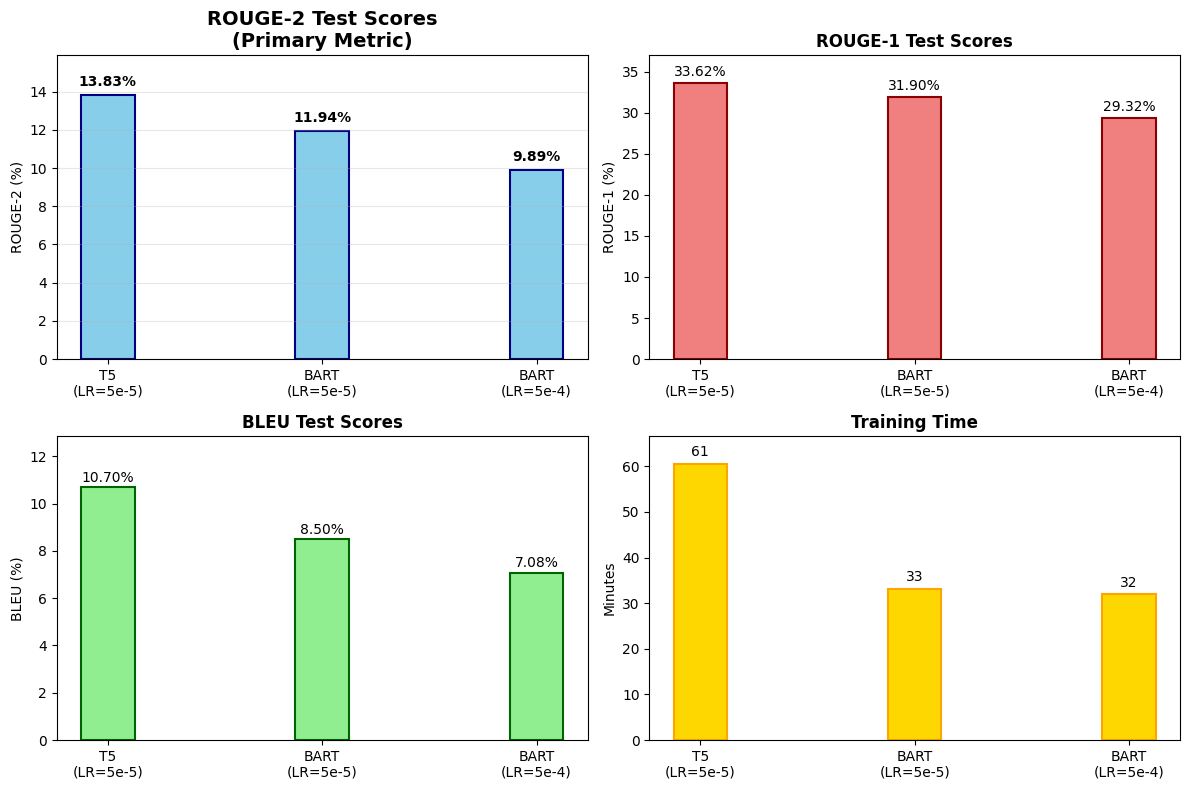

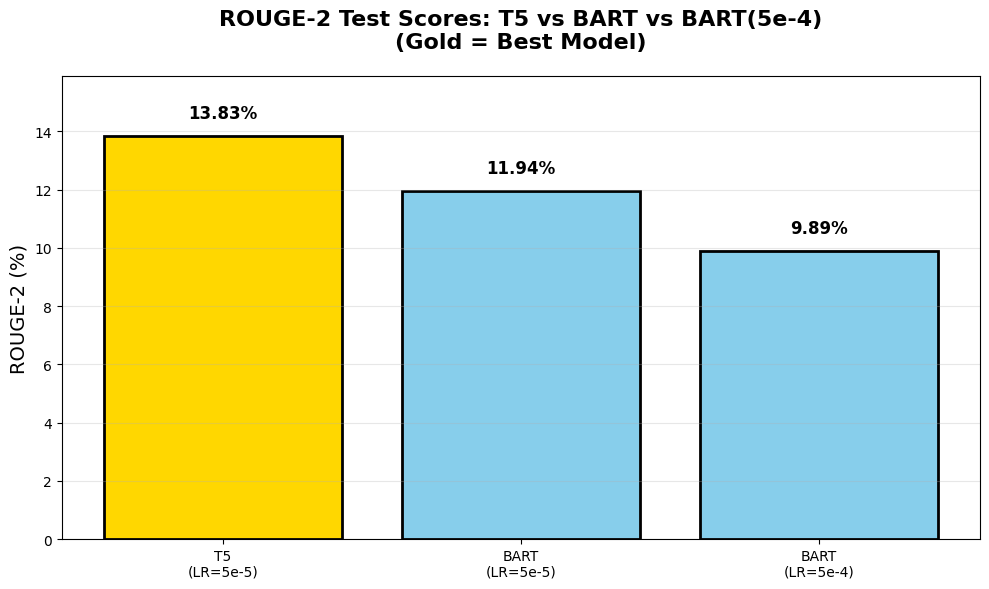


MODEL COMPARISON SUMMARY
Model                R2     R1     BLEU   Time    
------------------------------------------------------------
T5
(LR=5e-5)         13.83  33.62  10.70  60.5    
BART
(LR=5e-5)       11.94  31.90  8.50   33.2    
BART
(LR=5e-4)       9.89   29.32  7.08   32.0    

BEST ROUGE-2: T5
(LR=5e-5) (13.83%)


In [28]:
# All three models (all test set results)
# =============================================================================
models = ['T5\n(LR=5e-5)', 'BART\n(LR=5e-5)', 'BART\n(LR=5e-4)']
x = np.arange(len(models))
width = 0.25 

# Variables (ROUGE-2 primary, all metrics secondary)
rouge2_scores = [t5_rouge2_test, bart_rouge2_test, bart_exp_rouge2_test]
rouge1_scores = [t5_rouge1_test, bart_rouge1_test, bart_exp_rouge1_test]
bleu_scores = [t5_bleu_test, bart_bleu_test, bart_exp_bleu_test]
training_times = [t5_training_time_minutes, bart_training_time_minutes, bart_exp_training_time_minutes]

# FIGURE 1: ROUGE-2 COMPARISON (Primary Metric)
plt.figure(figsize=(12, 8))

#ROUGE-2
plt.subplot(2, 2, 1)
bars1 = plt.bar(x, rouge2_scores, width, label='ROUGE-2', color='skyblue', edgecolor='navy', linewidth=1.5)
plt.title('ROUGE-2 Test Scores\n(Primary Metric)', fontweight='bold', fontsize=14)
plt.ylabel('ROUGE-2 (%)')
plt.ylim(0, max(rouge2_scores)*1.15)
plt.xticks(x, models, rotation=0)

for i, (bar, score) in enumerate(zip(bars1, rouge2_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{score:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)

# ROUGE-1
plt.subplot(2, 2, 2)
bars2 = plt.bar(x, rouge1_scores, width, color='lightcoral', edgecolor='darkred', linewidth=1.5)
plt.title('ROUGE-1 Test Scores', fontweight='bold')
plt.ylabel('ROUGE-1 (%)')
plt.ylim(0, max(rouge1_scores)*1.1)
plt.xticks(x, models, rotation=0)
for i, (bar, score) in enumerate(zip(bars2, rouge1_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{score:.2f}%', ha='center', va='bottom')

# BLEU
plt.subplot(2, 2, 3)
bars3 = plt.bar(x, bleu_scores, width, color='lightgreen', edgecolor='darkgreen', linewidth=1.5)
plt.title('BLEU Test Scores', fontweight='bold')
plt.ylabel('BLEU (%)')
plt.ylim(0, max(bleu_scores)*1.2)
plt.xticks(x, models, rotation=0)
for i, (bar, score) in enumerate(zip(bars3, bleu_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{score:.2f}%', ha='center', va='bottom')

# TRAINING TIME
plt.subplot(2, 2, 4)
bars4 = plt.bar(x, training_times, width, color='gold', edgecolor='orange', linewidth=1.5)
plt.title('Training Time', fontweight='bold')
plt.ylabel('Minutes')
plt.ylim(0, max(training_times)*1.1)
plt.xticks(x, models, rotation=0)
for i, (bar, time) in enumerate(zip(bars4, training_times)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{time:.0f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('t5_bart_comparison.png', dpi=300, bbox_inches='tight')  # Publication quality
plt.show()


# FIGURE 2: WINNER HIGHLIGHT (ROUGE-2 Only)
plt.figure(figsize=(10, 6))
colors = ['skyblue' if i != np.argmax(rouge2_scores) else 'gold' for i in range(len(models))]
bars = plt.bar(models, rouge2_scores, color=colors, edgecolor='black', linewidth=2)

plt.title('ROUGE-2 Test Scores: T5 vs BART vs BART(5e-4)\n(Gold = Best Model)', 
          fontweight='bold', fontsize=16, pad=20)
plt.ylabel('ROUGE-2 (%)', fontsize=14)
plt.ylim(0, max(rouge2_scores)*1.15)


for i, (bar, score) in enumerate(zip(bars, rouge2_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{score:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    if i == np.argmax(rouge2_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                '', ha='center', va='bottom', fontweight='bold', 
                color='darkred', fontsize=14)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rouge2_winner.png', dpi=300, bbox_inches='tight')
plt.show()

# SUMMARY TABLE
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<20} {'R2':<6} {'R1':<6} {'BLEU':<6} {'Time':<8}")
print("-"*60)
for i, model in enumerate(models):
    print(f"{model:<20} {rouge2_scores[i]:<6.2f} {rouge1_scores[i]:<6.2f} {bleu_scores[i]:<6.2f} {training_times[i]:<8.1f}")

best_idx = np.argmax(rouge2_scores)
print(f"\nBEST ROUGE-2: {models[best_idx]} ({rouge2_scores[best_idx]:.2f}%)")
print("="*60)


In [51]:
#MODEL ARCHITECTURE CUSTOM ENCODER-DECODER (from scratch)

class PositionalEncoding(nn.Module):
    #Gives every position a unique "fingerprint" using sine/cosine waves, transformer now knows "word + position"
    def __init__(self, d_model, max_len=1024, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)  #creating empty position matrix Shape: [1024,512]
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1) #Shape [1024,1]
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)) #creating wavelengths
        pe[:, 0::2] = torch.sin(position * div_term) #for even dimensions -> sine waves
        pe[:, 1::2] = torch.cos(position * div_term) #for odd dimensions -> cosine waves
        pe = pe.unsqueeze(0) #[1,1024,512]
        self.register_buffer('pe', pe) 
    
    def forward(self, x):
        # x: [batch, seq_len, d_model] from embedding layer
        return self.dropout(x + self.pe[:, :x.size(1)])

class EncoderLayer(nn.Module):
    #Article reader: self-attention + feedforward -> understands word relationships
    def __init__(self, d_model, nhead, d_ff=2048, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout)  #Self attention - "who relates to who?"
        self.feed_forward = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        
        # Layer norms for "stabilizing training"
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, src, src_mask=None):
        #src means article words with position
        src2 = self.self_attn(src, src, src, attn_mask=src_mask)[0] #new info, words look at each other
        src = src + self.dropout(src2)  #residual
        src = self.norm1(src)
        src2 = self.feed_forward(src)
        src = src + self.dropout(src2) 
        src = self.norm2(src)
        return src

class DecoderLayer(nn.Module):
    def __init__(self, d_model, nhead, d_ff=2048, dropout=0.1):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout) #masked self-attention - "look at summary so far"
        self.cross_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout) #cross-attention look at ARTICLE for context
        self.feed_forward = nn.Sequential(   #deep thinking
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, tgt, memory, tgt_mask=None, memory_mask=None):
        tgt2 = self.self_attn(tgt, tgt, tgt, attn_mask=tgt_mask)[0] #masked self-attention - summary looks at itself
        tgt = tgt + self.dropout(tgt2)
        tgt = self.norm1(tgt)
        tgt2 = self.cross_attn(tgt, memory, memory, attn_mask=memory_mask)[0] #cross-attention
        tgt = tgt + self.dropout(tgt2)
        tgt = self.norm2(tgt)
        tgt2 = self.feed_forward(tgt) 
        tgt = tgt + self.dropout(tgt2)
        tgt = self.norm3(tgt)
        return tgt

class CustomEncoderDecoder(nn.Module):
    def __init__(self, vocab_size, d_model=512, nhead=8, num_layers=6, d_ff=2048, max_len=1024, dropout=0.1):
        super().__init__()
        self.src_embedding = nn.Embedding(vocab_size, d_model) #article words
        self.tgt_embedding = nn.Embedding(vocab_size, d_model) #summary words
        self.pos_encoder = PositionalEncoding(d_model, max_len, dropout)
        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, nhead, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, nhead, d_ff, dropout) for _ in range(num_layers)])
        self.fc_out = nn.Linear(d_model, vocab_size) 
        self.d_model = d_model
    
    def forward(self, src, tgt):
        src = self.src_embedding(src) * np.sqrt(self.d_model) #scale embeddings
        tgt = self.tgt_embedding(tgt) * np.sqrt(self.d_model)
        src = self.pos_encoder(src.transpose(0, 1))
        tgt = self.pos_encoder(tgt.transpose(0, 1))

        #Encoder layers
        memory = src
        for layer in self.encoder_layers:
            memory = layer(memory)
            
        #Decoder layers
        output = tgt
        for layer in self.decoder_layers:
            output = layer(output, memory)

        #returns word prediction logits
        return self.fc_out(output).transpose(0, 1) 
    
    def generate(self, input_ids, max_length=128, pad_token_id=None, eos_token_id=None, do_sample=False, top_k=50, temperature=1.0, min_length=10, **kwargs):
        #input_ids: tokenized articles ONLY
        self.eval()
        device = input_ids.device
        batch_size = input_ids.shape[0]
        
        if pad_token_id is None: pad_token_id = 0
        if eos_token_id is None: eos_token_id = 1
        
        # Encode article
        src_emb = self.src_embedding(input_ids) * np.sqrt(self.d_model)
        src = src_emb.transpose(0, 1)
        src = self.pos_encoder(src)
        memory = src
        for layer in self.encoder_layers:
            memory = layer(memory)
        
        # Start generation token by token
        generated = torch.full((batch_size, 1), pad_token_id, device=device, dtype=torch.long)
        finished = torch.zeros(batch_size, dtype=torch.bool, device=device)
        
        for step in range(max_length):
            tgt_emb = self.tgt_embedding(generated) * np.sqrt(self.d_model)
            tgt = tgt_emb.transpose(0, 1)
            tgt = self.pos_encoder(tgt)
            
            output = tgt
            for layer in self.decoder_layers:
                output = layer(output, memory)
            
            logits = self.fc_out(output)  
            next_token_logits = logits[-1]  
            
            if do_sample: #Creative mode
                next_token_logits = next_token_logits / temperature
                if top_k > 0:
                    # Keep only top-k tokens
                    top_k_logits, top_k_indices = torch.topk(next_token_logits, top_k, dim=-1)
                    # Mask out tokens not in top-k
                    next_token_logits = torch.full_like(next_token_logits, float('-inf'))
                    next_token_logits.scatter_(1, top_k_indices, top_k_logits)
                
                # Sample from distribution
                probs = torch.softmax(next_token_logits, dim=-1)
                next_token = torch.multinomial(probs, num_samples=1)
            else: #deterministic
                next_token = torch.argmax(next_token_logits, dim=-1, keepdim=True)
        
            if step < min_length:
                next_token = torch.where(
                    next_token == eos_token_id,
                    torch.full_like(next_token, pad_token_id),
                    next_token
                )
                
            # Mark finished sequences
            finished = finished | (next_token.squeeze(-1) == eos_token_id)
                
            # Replace tokens in finished sequences with pad
            next_token = torch.where(
                finished.unsqueeze(-1),
                torch.full_like(next_token, pad_token_id),
                next_token
            )
                
            generated = torch.cat([generated, next_token], dim=1)
                
            if finished.all():
                break
            
        return generated
                


**Architecture Summary**

A transformer-based summarization model built from scratch with 4 main components: embeddings + positional encoding, encoder (article understanding), decoder (summary generation), and output layer.

*1.Positional Encoding*

Gives each word position a unique "fingerprint" using sine/cosine waves at different frequencies. This step is crucial because transformers process all words simultaneously, so they need to know the order of words- for example to understand the difference between "dog chases cat" and "cat chases dog"

*2.Encoder*

Processes the input through 6 layers where each word looks at every other word to understand relationships (**Self-Attention**). Then **Feed-Forward** deep processes every word. Training is stabilized through **Residual Connections** and **Layer Norms**. The output is an encoded article representation that captures meaning and context.

*3.Decoder*

Generates the summary word-by-word through 6 layers. Each layer looks at the summary generated so far using **Masked Self-Attention**, examines the encoded article using **Cross-Attention** to know what to write next, and deep processes this information through **Feed-Forward** networks to predict the next word. **Residual Connections** and **Layer Norms** stabilize training throughout the process.

*4.Generation Process*

Creates summaries by **greedy decoding** that picks the most likely word (deterministic) and by **sampling** that picks from top-k most likely words (more creative)

In [52]:
#Tokenizer Setup - Matches T5
vocab_size = t5_tokenizer.vocab_size
pad_token_id = t5_tokenizer.pad_token_id

# Preprocess function
def preprocess_custom(examples, tokenizer):
    """
    Convert CNN/DailyMail → T5-format batches for CustomEncoderDecoder
    """
    inputs = ["summarize: " + doc for doc in examples["article"]]
    model_inputs = tokenizer(inputs, max_length=1024, truncation=True, padding="max_length")
    labels = tokenizer(examples["highlights"], max_length=128, truncation=True, padding="max_length")
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

#Dataset Tokenization
tokenized_custom = dataset_dict.map(
    lambda x: preprocess_custom(x, t5_tokenizer), 
    batched=True, 
    remove_columns=dataset_dict["train"].column_names
)

# Data Collator and DataLoaders
data_collator = DataCollatorForSeq2Seq(t5_tokenizer, model=None, return_tensors="pt", padding=True)

train_loader = DataLoader(
    tokenized_custom["train"], 
    batch_size=4, 
    shuffle=True, 
    collate_fn=data_collator
)
eval_loader = DataLoader(
    tokenized_custom["validation"], 
    batch_size=4, 
    collate_fn=data_collator
)
test_loader = DataLoader(
    tokenized_custom["test"].select(range(100)),  # 100 samples for fast ROUGE
    batch_size=4, 
    collate_fn=data_collator
)


In [53]:
# Training Loop - Matches previous models T5/BART 

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in dataloader:
        input_ids = batch["input_ids"].to(device)
        labels = batch["labels"].to(device)
        
        tgt_input = labels[:, :-1]
        tgt_output = labels[:, 1:]
        
        optimizer.zero_grad()
        output = model(input_ids, tgt_input)
        loss = criterion(output.reshape(-1, vocab_size), tgt_output.reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def evaluate_loss(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            
            tgt_input = labels[:, :-1]
            tgt_output = labels[:, 1:]
            
            output = model(input_ids, tgt_input)
            loss = criterion(output.reshape(-1, vocab_size), tgt_output.reshape(-1))
            total_loss += loss.item()
    
    return total_loss / len(dataloader)

In [54]:
# Training Execution - Matches T5/BART (2 epochs)
import time

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = CustomEncoderDecoder(
    vocab_size=vocab_size,
    d_model=512,
    nhead=8, 
    num_layers=6,
    d_ff=2048,
    dropout=0.1
).to(device)

optimizer = optim.Adam(model.parameters(), lr=5e-4, weight_decay=0.01)
criterion = nn.CrossEntropyLoss(ignore_index=pad_token_id)

print("Starting Custom Encoder-Decoder training...")
custom_start_time = time.time()

num_epochs = 2
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    eval_loss = evaluate_loss(model, eval_loader, criterion, device)
    print(f"Epoch {epoch+1}: Train Loss = {train_loss:.4f}, Eval Loss = {eval_loss:.4f}")

custom_end_time = time.time()
custom_training_time = custom_end_time - custom_start_time
print(f"Training completed in {custom_training_time:.2f} seconds ({custom_training_time/60:.2f} minutes)")
torch.save(model.state_dict(), "custom_encoder_decoder.pth")
print("Custom model saved!")



Using device: cuda
Starting Custom Encoder-Decoder training...
Epoch 1: Train Loss = 6.9714, Eval Loss = 6.9718
Epoch 2: Train Loss = 6.8291, Eval Loss = 6.7822
Training completed in 1058.94 seconds (17.65 minutes)
Custom model saved!


In [55]:
# 5.Evaluation on Test Set

def evaluate_custom(model, test_loader, tokenizer):
    model.eval()
    predictions = []
    references = []
    
    with torch.no_grad():
        for batch in test_loader:
            input_ids = batch["input_ids"].to(device)
            labels = batch["labels"].to(device)
            
            labels = torch.where(labels != -100, labels, tokenizer.pad_token_id)
            
            outputs = model.generate(
                input_ids, 
                max_length=128,
                min_length=10,
                do_sample=True,
                top_k=50,
                temperature=0.7,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id
            )

            
            preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
            refs = tokenizer.batch_decode(labels, skip_special_tokens=True)
            
            predictions.extend(preds)
            references.extend(refs)
    
    return predictions, references

print("Evaluating on TEST set")
predictions, references = evaluate_custom(model, test_loader, t5_tokenizer)
print("\nSample predictions:", predictions[:2])
print("Sample references:", references[:2])

rouge_results = rouge.compute(predictions=predictions, references=references)
bleu_results = bleu.compute(predictions=predictions, references=references)

print("\n CUSTOM ENCODER-DECODER TEST RESULTS:")
print(f"ROUGE-1: {rouge_results['rouge1']:.4f}")
print(f"ROUGE-2: {rouge_results['rouge2']:.4f}")
print(f"ROUGE-L: {rouge_results['rougeL']:.4f}")
print(f"BLEU:   {bleu_results['bleu']:.4f}")

results = {
    "rouge1": rouge_results['rouge1'],
    "rouge2": rouge_results['rouge2'],
    "rougeL": rouge_results['rougeL'],
    "bleu": bleu_results['bleu']
}

custom_rouge2_test = rouge_results['rouge2'] *100
custom_rouge1_test = rouge_results['rouge1'] *100
custom_bleu_test = bleu_results['bleu']*100
custom_training_time_minutes = custom_training_time / 60 
with open("custom_model_results.pkl", "wb") as f:
    pickle.dump(results, f)

print("Results saved: custom_model_results.pkl")


Evaluating on TEST set

Sample predictions: ['. . . .', '. is . . .']
Sample references: ['Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .', 'Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field . "She\'s a true miracle dog and she deserves a good life," says Sara Mellado, who is looking for a home for Theia .']

 CUSTOM ENCODER-DECODER TEST RESULTS:
ROUGE-1: 0.0597
ROUGE-2: 0.0015
ROUGE-L: 0.0534
BLEU:   0.0000
Results saved: custom_model_results.pkl


In [56]:
#Show 5 examples predictions vs references
print("\nSample predictions:")
for i in range(5):
    print(f"\nPred {i}: {predictions[i]}")
    print(f"Ref  {i}: {references[i]}")


Sample predictions:

Pred 0: . . . .
Ref  0: Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June . Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

Pred 1: . is . . .
Ref  1: Theia, a bully breed mix, was apparently hit by a car, whacked with a hammer and buried in a field . "She's a true miracle dog and she deserves a good life," says Sara Mellado, who is looking for a home for Theia .

Pred 2: the the . the the He, his .
Ref  2: Mohammad Javad Zarif has spent more time with John Kerry than any other foreign minister . He once participated in a takeover of the Iranian Consulate in San Francisco . The Iranian foreign minister tweets in English .

Pred 3: - for . The . .
Ref  3: 17 Americans were exposed to the Ebola virus while in Sierra Leone in March . Another person was diagnosed with the disease and taken to hospital in Maryland . National Institutes 

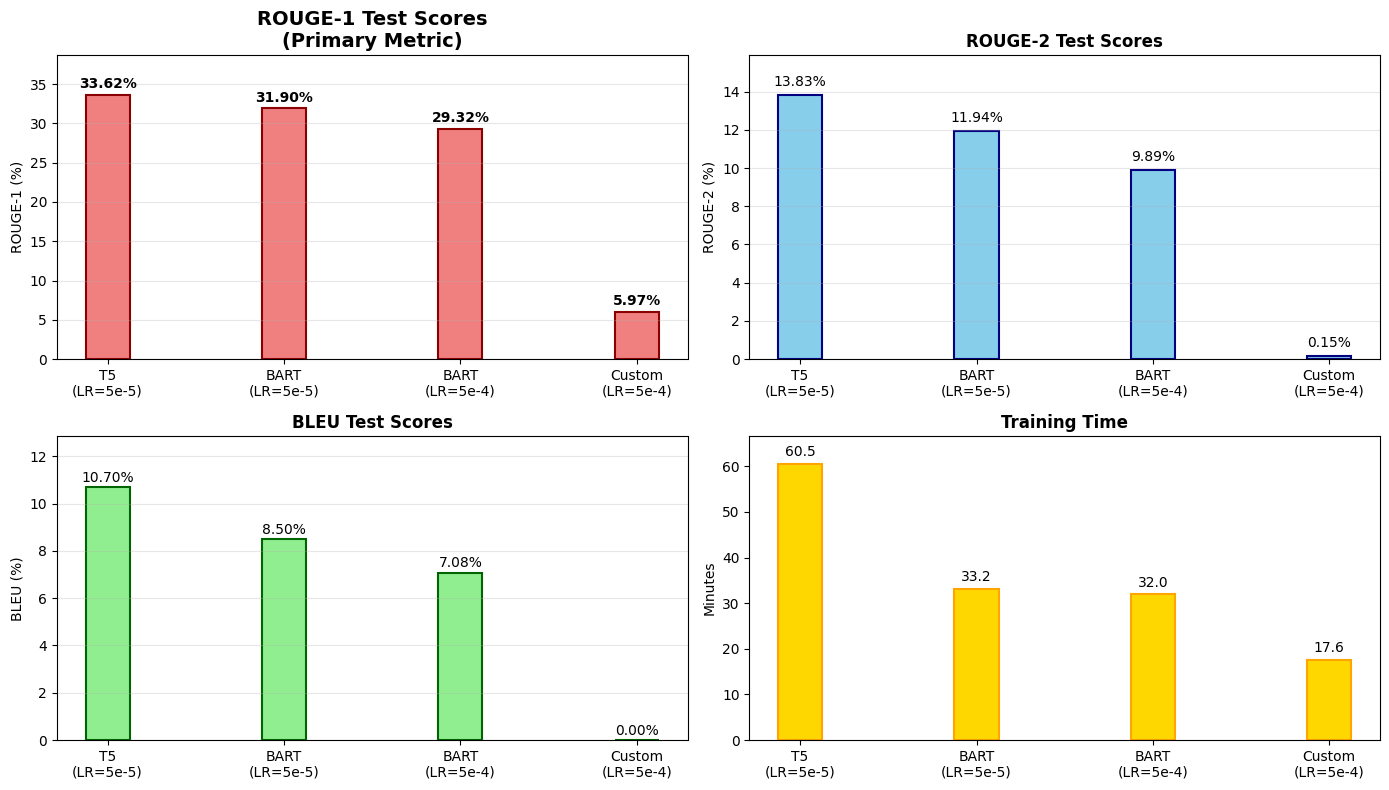

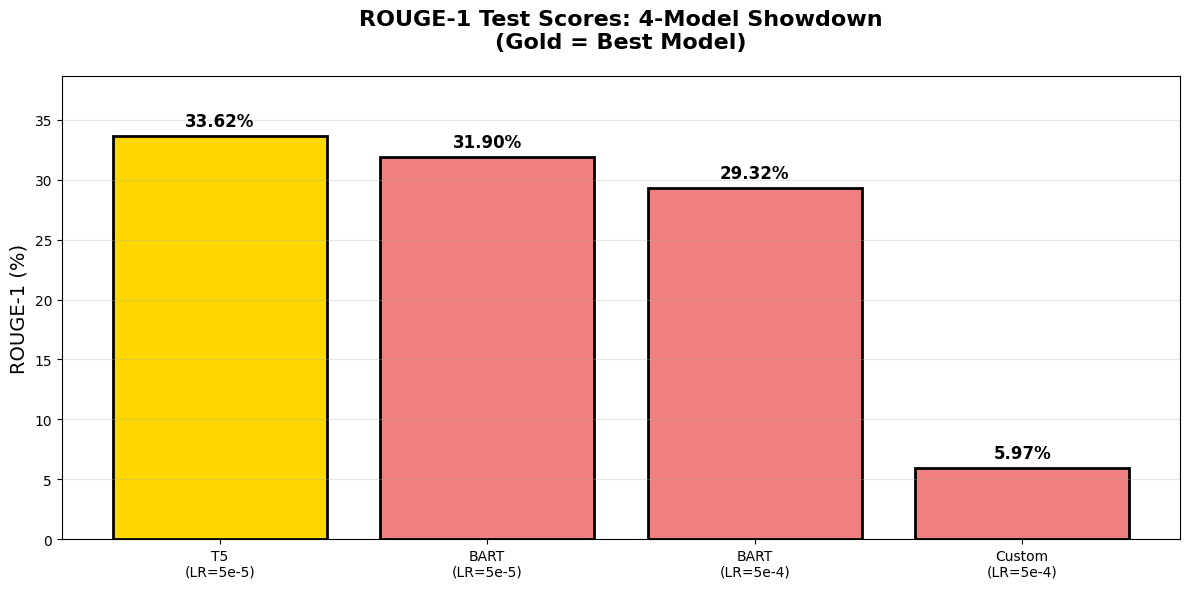


4-MODEL COMPARISON SUMMARY (CNN/DailyMail Test Set)
Model                       R1      R2    BLEU     Time   Params
---------------------------------------------------------------------------
T5 (LR=5e-5)            33.62%  13.83%  10.70%    60.5m     220M
BART (LR=5e-5)          31.90%  11.94%   8.50%    33.2m     139M
BART (LR=5e-4)          29.32%   9.89%   7.08%    32.0m     139M
Custom (LR=5e-4)         5.97%   0.15%   0.00%    17.6m     ~60M


In [ ]:
# All FOUR models 
models = ['T5\n(LR=5e-5)', 'BART\n(LR=5e-5)', 'BART\n(LR=5e-4)', 'Custom\n(LR=5e-4)']
x = np.arange(len(models)) 
width = 0.25 

rouge1_scores = [t5_rouge1_test, bart_rouge1_test, bart_exp_rouge1_test, custom_rouge1_test]
rouge2_scores = [t5_rouge2_test, bart_rouge2_test, bart_exp_rouge2_test, custom_rouge2_test]
bleu_scores = [t5_bleu_test, bart_bleu_test, bart_exp_bleu_test, custom_bleu_test]
training_times = [t5_training_time_minutes, bart_training_time_minutes, bart_exp_training_time_minutes, custom_training_time_minutes]

# FIGURE 1: 4-METRIC COMPARISON
plt.figure(figsize=(14, 8))

# ROUGE-1 (Primary - most common metric)
plt.subplot(2, 2, 1)
bars1 = plt.bar(x, rouge1_scores, width, label='ROUGE-1', color='lightcoral', edgecolor='darkred', linewidth=1.5)
plt.title('ROUGE-1 Test Scores', fontweight='bold', fontsize=14)
plt.ylabel('ROUGE-1 (%)')
plt.ylim(0, max(rouge1_scores)*1.15)
plt.xticks(x, models, rotation=0)

for i, (bar, score) in enumerate(zip(bars1, rouge1_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{score:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', alpha=0.3)

# ROUGE-2
plt.subplot(2, 2, 2)
bars2 = plt.bar(x, rouge2_scores, width, color='skyblue', edgecolor='navy', linewidth=1.5)
plt.title('ROUGE-2 Test Scores\n(Primary Metric)', fontweight='bold')
plt.ylabel('ROUGE-2 (%)')
plt.ylim(0, max(rouge2_scores)*1.15)
plt.xticks(x, models, rotation=0)
for i, (bar, score) in enumerate(zip(bars2, rouge2_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, 
             f'{score:.2f}%', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)

# BLEU
plt.subplot(2, 2, 3)
bars3 = plt.bar(x, bleu_scores, width, color='lightgreen', edgecolor='darkgreen', linewidth=1.5)
plt.title('BLEU Test Scores', fontweight='bold')
plt.ylabel('BLEU (%)')
plt.ylim(0, max(bleu_scores)*1.2)
plt.xticks(x, models, rotation=0)
for i, (bar, score) in enumerate(zip(bars3, bleu_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             f'{score:.2f}%', ha='center', va='bottom')

plt.grid(axis='y', alpha=0.3)

# TRAINING TIME
plt.subplot(2, 2, 4)
bars4 = plt.bar(x, training_times, width, color='gold', edgecolor='orange', linewidth=1.5)
plt.title('Training Time', fontweight='bold')
plt.ylabel('Minutes')
plt.ylim(0, max(training_times)*1.1)
plt.xticks(x, models, rotation=0)
for i, (bar, time) in enumerate(zip(bars4, training_times)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
             f'{time:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('4_models_comparison.png', dpi=300, bbox_inches='tight') 
plt.show()

# FIGURE 2: WINNER HIGHLIGHT (ROUGE-2)
plt.figure(figsize=(12, 6))
colors = ['lightcoral' if i != np.argmax(rouge2_scores) else 'gold' for i in range(len(models))]
bars = plt.bar(models, rouge2_scores, color=colors, edgecolor='black', linewidth=2)

plt.title('ROUGE-1 Test Scores: 4-Model Showdown\n(Gold = Best Model)', 
          fontweight='bold', fontsize=16, pad=20)
plt.ylabel('ROUGE-1 (%)', fontsize=14)
plt.ylim(0, max(rouge2_scores)*1.15)

for i, (bar, score) in enumerate(zip(bars, rouge2_scores)):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             f'{score:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
    if i == np.argmax(rouge2_scores):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, 
                '', ha='center', va='bottom', fontweight='bold', 
                color='darkred', fontsize=14)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('rouge1_4models_winner.png', dpi=300, bbox_inches='tight')
plt.show()

# SUMMARY TABLE - 
print("\n" + "="*75)
print("4-MODEL COMPARISON SUMMARY (CNN/DailyMail Test Set)")
print("="*75)
print(f"{'Model':<22} {'R1':>7} {'R2':>7} {'BLEU':>7} {'Time':>8} {'Params':>8}")
print("-"*75)
model_names = ['T5 (LR=5e-5)', 'BART (LR=5e-5)', 'BART (LR=5e-4)', 'Custom (LR=5e-4)']
params_list = ['220M', '139M', '139M', '~60M']

for i, model_name in enumerate(model_names):
    print(f"{model_name:<22} {rouge1_scores[i]:>6.2f}% {rouge2_scores[i]:>6.2f}% {bleu_scores[i]:>6.2f}% {training_times[i]:>7.1f}m {params_list[i]:>8}")

print("="*75)